# Importing Library

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Importing and reading files(Csv)

In [2]:
Corona_data = pd.read_csv("covid19_Confirmed_dataset.csv")
Corona_data.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


# Removing Unnecessory Columns Like lat/long and creating Country/Region as Index

In [3]:
# Removing unnecessory column
Corona_data_clean = Corona_data.drop(["Lat","Long","Province/State"], axis=1)
Corona_data_clean_aggregated = Corona_data_clean.groupby("Country/Region").sum()
Corona_data_clean_aggregated.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
Albania,0,0,0,0,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
Algeria,0,0,0,0,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
Andorra,0,0,0,0,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
Angola,0,0,0,0,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


# Plotting the graph with country name and legend : Number of Country and Name given by user 

ENTER THE NUMBER OF COUNTRY YOU WANT TO PLOT:    2
No. 1 COUNTRY NAME YOU WANT TO PLOT:  China
No. 2 COUNTRY NAME YOU WANT TO PLOT:  India


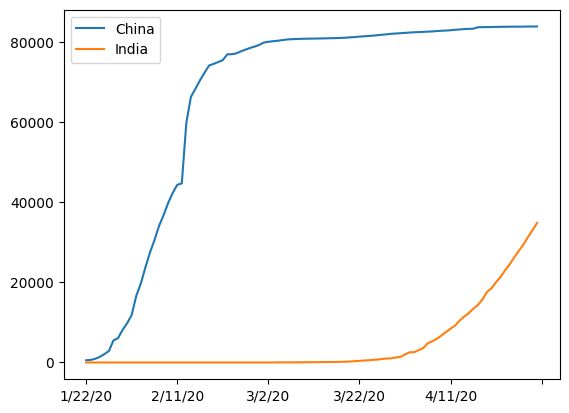

In [9]:
number = int(input("ENTER THE NUMBER OF COUNTRY YOU WANT TO PLOT:   "))
for i in range(number):
   c_i = input(f"No. {i+1} COUNTRY NAME YOU WANT TO PLOT: ")
   Corona_data_clean_aggregated.loc[c_i].plot()
plt.legend()

# Finding the derivative of the curve i.e how many cases are reported everyday

In [10]:
country = input("ENTER THE NAME OF COUNTRY ")
max_value = int(Corona_data_clean_aggregated.loc[country].diff().max())
print("THE MAXIMUM NUMBER OF CASE THAT IS REPORTED IN {} IS \t{}".format(country,max_value))

ENTER THE NAME OF COUNTRY  Bhutan


THE MAXIMUM NUMBER OF CASE THAT IS REPORTED IN Bhutan IS 	1


In [11]:
Country = list(Corona_data_clean_aggregated.index)
max_infection_rates = []

for c in Country:
    max_infection_rates.append(int(Corona_data_clean_aggregated.loc[c].diff().max()))
Corona_data_clean_aggregated["Max_infection_rates"] = max_infection_rates
new_clean_corona_data = pd.DataFrame(Corona_data_clean_aggregated["Max_infection_rates"])
new_clean_corona_data.head()

,Max_infection_rates
Country/Region,
Afghanistan,232
Albania,34
Algeria,199
Andorra,43
Angola,5


# Importing Happiness Report file

In [12]:
WHappyness_data = pd.read_csv("worldwide_happiness_report.csv")
WHappyness_data

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


# Removing Useless Columns (Overall rank, Score, Generosity, Perceptions of corruption)

In [13]:
WHappyness_data_clean = WHappyness_data.drop(["Overall rank", "Score", "Generosity", "Perceptions of corruption"], axis=1)
WHappyness_data_clean.head()

,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
0,Finland,1.340,1.587,0.986,0.596
1,Denmark,1.383,1.573,0.996,0.592
2,Norway,1.488,1.582,1.028,0.603
3,Iceland,1.380,1.624,1.026,0.591
4,Netherlands,1.396,1.522,0.999,0.557


# Setting an Index 

In [14]:
WHappyness_data_clean.set_index("Country or region",inplace=True)

# Joinning two data from Covid_19 file and world happiness report file that has been cleaned

In [15]:
new_data = new_clean_corona_data.join(WHappyness_data_clean, how = "inner")

# Finding the Correlation of the data 

In [16]:
new_data.corr()

,Max_infection_rates,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Max_infection_rates,1.000000,0.250118,0.191958,0.289263,0.078196
GDP per capita,0.250118,1.000000,0.759468,0.863062,0.394603
Social support,0.191958,0.759468,1.000000,0.765286,0.456246
Healthy life expectancy,0.289263,0.863062,0.765286,1.000000,0.427892
Freedom to make life choices,0.078196,0.394603,0.456246,0.427892,1.000000


####        The correlaction result suggest that infection rate is linearly correlated to GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices on increase of one of the parameter the infection rate also increases.

# Visualization of Data or plotting the data between the MAx infection rates and other parameters

PROVIDE PARAMETER FOR WHICH YOU WANT TO PLOT THE SCATTER DIAGRAM WITH MAX INFECTION RATE 
 THE PARAMETER YOU CAN PROVIDE ARE 

 GDP per capita 
 Social support 
 Healthy life expectancy	
 Freedom to make life choices

		 Healthy life expectancy


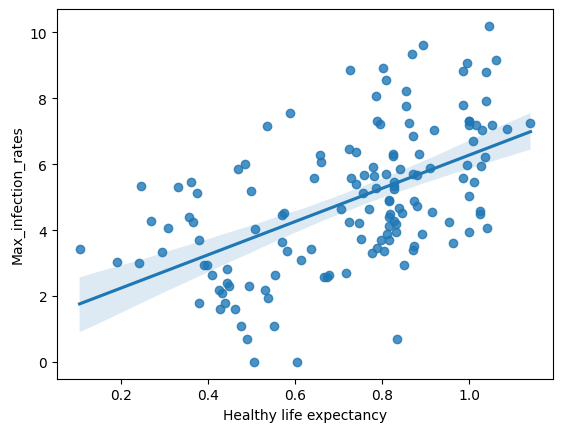

In [18]:
row = input("PROVIDE PARAMETER FOR WHICH YOU WANT TO PLOT THE SCATTER DIAGRAM WITH MAX INFECTION RATE \n THE PARAMETER YOU CAN PROVIDE ARE \n\n GDP per capita \n Social support \n Healthy life expectancy	\n Freedom to make life choices\n\n\t\t")

if row in ["GDP per capita","Social support","Healthy life expectancy","Freedom to make life choices"]:
    x = new_data[row]
    y = new_data["Max_infection_rates"]
    y = np.log (y)
    sns.regplot(x=x,y=y)
else:
    print("\nsorry! Wrong Input")